# Basic example 1

Here you can learn about the basic data structure of ODYM and also about some of the additional features I developed for bioDYM. It shows a simple example system for a biomass MFA for a few years, tracking biomass and carbon using transfer coefficients.

<img src="system_flow_diagram.svg" alt="system_flow_diagram">

## 0 Load packages

In [1]:
### Load packages ###

# Load general libraries
import sys, os
import numpy as np
import pandas as pd
from scipy.stats import lognorm
import xlsxwriter
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator,
                               FormatStrFormatter,
                               AutoMinorLocator)
import warnings
import re
from collections import defaultdict
from scipy.optimize import minimize
import copy

# Load ODYM package
# Add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())),'framework', 'ODYM-master_20241127', 'odym', 'modules')) 

# Import the ODYM class file
import ODYM_Classes as msc 
# Import the ODYM function file
import ODYM_Functions as msf
# Import the dynamic stock model library
import dynamic_stock_model as dsm 


# Load bioDYM_addon
# Add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'framework', 'bioDYM_add-on', 'modules')) 

# Import classes for first order model process
import bioDYM_classes as bicl
# Import plotting functions
import bioDYM_plotting as bipl
# Import export functions
import bioDYM_export as bix




# Enables plotting directly in the notebook (in most cases this is already enabled)
%matplotlib inline

## 1 Definition of system and relevant aspects

In [2]:
ModelClassification  = {} # Create empty dictionary of model classifications

MyYears = list(np.arange(2025,2029)) # Define period of analysis and create list of years
ModelClassification['Time'] = msc.Classification(Name = 'Time', Dimension = 'Time', ID = 1,
                                                 Items = MyYears)
# Classification for time labelled 'Time' must always be present, with Items containing a list of ordered integers representing years, months, or other discrete time intervals


ModelClassification['Element'] = msc.Classification(Name = 'Elements', Dimension = 'Element', 
                                                    ID = 2, Items = ['Biomass', 'Carbon'])
# Classification for elements labelled 'Element' must always be present, with Items containing a list of the symbols of the elements covered.
# Here, other elements (like N or P) could be added to the ODYM MFA system

# Get model time start, end, and duration:
Model_Time_Start = int(min(ModelClassification['Time'].Items))
Model_Time_End   = int(max(ModelClassification['Time'].Items))
Model_Duration   = Model_Time_End - Model_Time_Start


In [3]:
IndexTable = pd.DataFrame({'Aspect'        : ['Time','Element'], # 'Time' and 'Element' must be present!
                           'Description'   : ['Model aspect "time"', 'Model aspect "Element"'],
                           'Dimension'     : ['Time','Element'], # 'Time' and 'Element' are also dimensions
                           'Classification': [ModelClassification[Aspect] for Aspect in ['Time','Element']],
                           'IndexLetter'   : ['t','e']}) # Unique one letter (upper or lower case) indices to be used later for calculations.

IndexTable.set_index('Aspect', inplace = True) # Default indexing of IndexTable, other indices are produced on the fly

IndexTable #Classification refers to ODYM structure, is not relevant for using the template 

,Description,Dimension,Classification,IndexLetter
Aspect,,,,
Time,"Model aspect ""time""",Time,<ODYM_Classes.Classification object at 0x7fa30...,t
Element,"Model aspect ""Element""",Element,<ODYM_Classes.Classification object at 0x7fa30...,e


In [4]:
# Initialize MFA system
Dyn_MFA_System = msc.MFAsystem(Name = 'TestSystem', 
                      Geogr_Scope = 'TestRegion', 
                      Unit = 'Mg', 
                      ProcessList = [], 
                      FlowDict = {}, 
                      StockDict = {},
                      ParameterDict = {}, 
                      Time_Start = Model_Time_Start, 
                      Time_End = Model_Time_End, 
                      IndexTable = IndexTable, 
                      Elements = IndexTable.loc['Element'].Classification.Items) 

In [5]:
# Define all processes and specify an ID (ID is used to assign flows and stocks to processes)
Dyn_MFA_System.ProcessList = [] 
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Environment' , ID   = 0))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Processing' , ID   = 1))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Food'    , ID   = 2))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Biowaste'    , ID   = 3))


In [6]:
# FlowDict 
Dyn_MFA_System.FlowDict['F_0_1'] = msc.Flow(Name = 'F_0_1', P_Start = 0, P_End = 1,
                                            Indices = 't,e', Values=None, Uncert = np.zeros(shape = (len(MyYears),len(ModelClassification['Element'].Items))))
Dyn_MFA_System.FlowDict['F_1_2'] = msc.Flow(Name = 'F_1_2', P_Start = 1, P_End = 2,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_1_3'] = msc.Flow(Name = 'F_1_3', P_Start = 1, P_End = 3,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_3_0'] = msc.Flow(Name = 'F_3_4', P_Start = 3, P_End = 0,
                                            Indices = 't,e', Values=None)


# StockDict 
Dyn_MFA_System.StockDict['dS_2']  = msc.Stock(Name = 'dS_2', P_Res = 2, Type = 1,
                                              Indices = 't,e', Values=None)
Dyn_MFA_System.StockDict['S_2']   = msc.Stock(Name = 'S_2', P_Res = 2, Type = 0,
                                              Indices = 't,e', Values=None)


Dyn_MFA_System.StockDict['dS_3']  = msc.Stock(Name = 'dS_3', P_Res = 3, Type = 1,
                                              Indices = 't,e', Values=None)
Dyn_MFA_System.StockDict['S_3']   = msc.Stock(Name = 'S_3', P_Res = 3, Type = 0,
                                              Indices = 't,e', Values=None)


# Assign empty arrays to flows according to dimensions
Dyn_MFA_System.Initialize_FlowValues() 
Dyn_MFA_System.Initialize_StockValues() 

## 2 Data input into model

In [7]:
# Get biomass input data from .xlsx
file_path = 'input_data.xlsx'
input_data = pd.read_excel(file_path, sheet_name = None, header = 0)
input_data

{'biomass':    Year  F_0_1  TC_1_2  TC_1_3  TC_3_0
 0  2025    100     0.7     0.3     0.5
 1  2026    110     0.7     0.3     0.5
 2  2027    120     0.7     0.3     0.5
 3  2028    130     0.7     0.3     0.5,
 'carbon':    Year  F_0_1  TC_1_2  TC_1_3  TC_3_0
 0  2025     50    0.70    0.30     0.5
 1  2026     55    0.75    0.25     0.5
 2  2027     60    0.80    0.20     0.5
 3  2028     65    0.85    0.15     0.5}

In [8]:
# ParameterDict 

ParameterDict = {}


ParameterDict['F_0_1']  = msc.Parameter(Name = 'F_0_1', ID = 1, P_Res = 1,
                                         Indices = 't,e',
                                        Values = None, Unit = 't/yr')


ParameterDict['TC_1_2'] = msc.Parameter(Name = 'TC_1_2',  ID = 2, P_Res = 1,
                                          Indices = 't,e',
                                         Values = None, Unit = '1')
ParameterDict['TC_1_3'] = msc.Parameter(Name = 'TC_1_3', ID = 3, P_Res = 1,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')
ParameterDict['TC_3_0'] = msc.Parameter(Name = 'TC_3_0',  ID = 4, P_Res = 3,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')


# Assign parameter dictionary to MFA system:
Dyn_MFA_System.ParameterDict = ParameterDict

# Assign empty arrays to parameters according to dimensions, analogous to the procedure in FlowDict and StockDict
Dyn_MFA_System.Initialize_ParameterValues()

In [9]:
# Add all input data to ParametersDict
# Parameters, Flows and stocks have the shape (number of years, number of elements)

for data_sheet in input_data:
    if data_sheet == 'biomass':
        for col in input_data[data_sheet].columns[1:]:
            Dyn_MFA_System.ParameterDict[col].Values[:, 0] = input_data[data_sheet][col]
    else:
        for col in input_data[data_sheet].columns[1:]:
            Dyn_MFA_System.ParameterDict[col].Values[:, 1] = input_data[data_sheet][col]



for element in Dyn_MFA_System.ParameterDict:
    print(Dyn_MFA_System.ParameterDict[element].Name)
    print(Dyn_MFA_System.ParameterDict[element].Values)

F_0_1
[[100.  50.]
 [110.  55.]
 [120.  60.]
 [130.  65.]]
TC_1_2
[[0.7  0.7 ]
 [0.7  0.75]
 [0.7  0.8 ]
 [0.7  0.85]]
TC_1_3
[[0.3  0.3 ]
 [0.3  0.25]
 [0.3  0.2 ]
 [0.3  0.15]]
TC_3_0
[[0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]]


In [10]:
# Check whether flow value arrays match their indices, etc. See ODYM method documentation.
Dyn_MFA_System.Consistency_Check() 

(True, True, True)

## 3 MFA Calculations

In [11]:
# Calculate results based on input data

Dyn_MFA_System.FlowDict['F_0_1'].Values = Dyn_MFA_System.ParameterDict['F_0_1'].Values

Dyn_MFA_System.FlowDict['F_1_2'].Values = Dyn_MFA_System.FlowDict['F_0_1'].Values * Dyn_MFA_System.ParameterDict['TC_1_2'].Values

Dyn_MFA_System.FlowDict['F_1_3'].Values = Dyn_MFA_System.FlowDict['F_0_1'].Values * Dyn_MFA_System.ParameterDict['TC_1_3'].Values

Dyn_MFA_System.FlowDict['F_3_0'].Values = Dyn_MFA_System.FlowDict['F_1_3'].Values * Dyn_MFA_System.ParameterDict['TC_3_0'].Values





Dyn_MFA_System.StockDict['dS_2'].Values = Dyn_MFA_System.FlowDict['F_1_2'].Values

Dyn_MFA_System.StockDict['dS_3'].Values = Dyn_MFA_System.FlowDict['F_1_3'].Values - Dyn_MFA_System.FlowDict['F_3_0'].Values


Dyn_MFA_System.StockDict['S_2'].Values = Dyn_MFA_System.StockDict['S_2'].Values + Dyn_MFA_System.StockDict['dS_2'].Values.cumsum(axis = 0)

Dyn_MFA_System.StockDict['S_3'].Values = Dyn_MFA_System.StockDict['dS_3'].Values.cumsum(axis = 0)




### 3.1.4 Final Mass balance check

In [12]:
Bal = Dyn_MFA_System.MassBalance()
print(Bal.shape) # dimensions of balance are: time step x process x element
print(np.abs(Bal).sum(axis = 0).sum(axis = 1)) # reports the sum of all absolute balancing errors by process.

(4, 4, 2)
[1.59872116e-14 3.19744231e-14 0.00000000e+00 0.00000000e+00]


## 4 Presentation of results

### 4.1 Simple plots

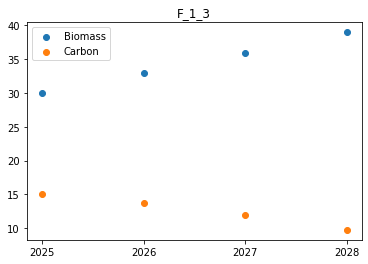

In [13]:
time = Dyn_MFA_System.IndexTable['Classification']['Time'].Items
flow_values = Dyn_MFA_System.FlowDict['F_1_3'].Values
fig, ax = plt.subplots()
# Loop over columns in the flow values (Biomass, Carbon)
for i, element in enumerate(ModelClassification['Element'].Items):
    ax.scatter(time, flow_values[:, i], label=element)

ax.set_title("F_1_3")
ax.legend(ModelClassification['Element'].Items)
ax.xaxis.set_major_locator(MultipleLocator(1))
plt.show()


### 4.2 Interactive Sankey diagram

In [14]:
# Here, the data of the ODYM MFA system is extracted and put into an applicable form for the interactive Sankey diagram 
# Choose colors for flows
colors_flows = []
colors_flows.extend(["darkseagreen" for i in range(2)])
colors_flows.extend(["tan" for i in range(2)])


# Choose colors for processes
colors_processes = ["darkseagreen", "darkseagreen", "darkseagreen", "tan"]


In [15]:
# Apply formula 
# If diagram does not show, try enableling the widgetsnbextension 
# by running: jupyter nbextension enable --py --sys-prefix widgetsnbextension
excluded_flows = {''}
bipl.sankey_results(Dyn_MFA_System, MyYears, ModelClassification, colors_flows, colors_processes, excluded_flows)

FigureWidget({
    'data': [{'link': {'color': [darkseagreen, darkseagreen, tan, tan],
                       'source': [0, 1, 1, 3],
                       'target': [1, 2, 3, 0],
                       'value': [100.0, 50.0]},
              'node': {'color': [darkseagreen, darkseagreen, darkseagreen, tan],
                       'label': [Environment, Processing, Food, Biowaste],
                       'line': {'color': 'black', 'width': 0.5},
                       'pad': 80,
                       'thickness': 10},
              'type': 'sankey',
              'uid': '3c1aff69-d62f-4f1d-acbd-465c73f742a5'}],
    'layout': {'height': 800,
               'template': '...',
               'title': {'text': 'System Sankey diagram Biomass (years 2025-2028) [t]'},
               'width': 1000}
})

interactive(children=(Dropdown(description='element:', options=('Biomass', 'Carbon'), value='Biomass'), IntSli…

### 4.3 Interactive stock plots

In [16]:
bipl.bar_stocks_results(Dyn_MFA_System, MyYears, ModelClassification, colors_processes)

FigureWidget({
    'data': [{'marker': {'color': ['darkseagreen', 'tan']},
              'type': 'bar',
              'uid': '8ea36ef5-7713-4510-b8a4-1ecfbb4d4fea',
              'x': [Food, Biowaste],
              'y': [70.0, 35.0]}],
    'layout': {'template': '...',
               'title': {'text': 'System stocks diagram Biomass (years 2025-2028) [t]'},
               'yaxis': {'range': [0, 354.20000000000005]}}
})

interactive(children=(Dropdown(description='element:', options=('Biomass', 'Carbon'), value='Biomass'), IntSli…

### 4.4 Excel export

In [17]:
bix.export_xlsx(Dyn_MFA_System, MyYears, ModelClassification)